# Sprawozdanie: uczenie ze wzmocnieniem w Gymnasium

**Temat:** LunarLanderContinuous + PPO (`stable-baselines3`)  
**Autorzy:** Antoni Pater, Mateusz Sobiech  

## Cel i zakres zadania 
Notebook realizuje wymagania zadania:
1. Wybrane środowisko Gymnasium ze stanami ciągłymi: `LunarLanderContinuous`.
2. Wybrany algorytm z `stable-baselines3`: `PPO` (Proximal Policy Optimization).
3. Porównanie **3 zestawów hiperparametrów**.
4. Dla każdego zestawu: **10 uruchomień** (różne ziarna) i minimum **300 000 kroków czasowych** na uruchomienie.
5. Wykresy krzywych uczenia: średnia nagroda i odchylenie standardowe.
6. Opis środowiska, algorytmu, hiperparametrów, czasu kroku/epizodu oraz wnioski.

In [2]:
# Imports i ustawienia
import csv
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed

# Katalog wyjściowy na wykresy i tabele do raportu
OUTPUT_DIR = Path("report_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device ->", device)
print("gym version ->", gym.__version__)
print("output dir ->", OUTPUT_DIR.resolve())

device -> cpu
gym version -> 0.29.1
output dir -> C:\Users\MateuszOmen\Desktop\studia\sem6\inteligencja_obliczeniowa_analiza_danych_cyfrowych\lab5\inteligencja_obliczeniowa_w_analizie_danych\lab5\report_outputs


In [3]:
# fragment kodu wyłączenie do celów osobistych -> łatwiejszego trenowania
import sys
import atexit

if sys.platform == "win32":
    import ctypes

    ES_CONTINUOUS = 0x80000000
    ES_SYSTEM_REQUIRED = 0x00000001
    ES_DISPLAY_REQUIRED = 0x00000002

    ctypes.windll.kernel32.SetThreadExecutionState(
        ES_CONTINUOUS | ES_SYSTEM_REQUIRED | ES_DISPLAY_REQUIRED
    )

    def _clear_sleep_blocker():
        ctypes.windll.kernel32.SetThreadExecutionState(ES_CONTINUOUS)

    atexit.register(_clear_sleep_blocker)
    print("Blokada usypiania aktywna: komputer nie powinien przejść w uśpienie podczas treningu.")
else:
    print("Blokada usypiania pominięta: działa tylko na Windows.")

Blokada usypiania aktywna: komputer nie powinien przejść w uśpienie podczas treningu.


## Charakterystyka środowiska i algorytmu

### Środowisko: `LunarLanderContinuous`
Środowisko modeluje sterowanie lądownikiem księżycowym z ciągłą przestrzenią akcji.
Agent obserwuje ciągły wektor stanu opisujący m.in. położenie, prędkości, orientację i kontakt nóg z podłożem.
Nagroda premiuje bezpieczne lądowanie blisko środka lądowiska, a karze za zderzenia oraz nadmierne zużycie paliwa.
Jest to klasyczny benchmark ciągłej kontroli, dobrze nadający się do porównywania jakości polityk i stabilności treningu.

### Algorytm: `PPO` (Proximal Policy Optimization)
PPO jest algorytmem on-policy opartym na architekturze actor-critic.
Uczy politykę przez kontrolowane, małe aktualizacje, co zwykle daje stabilniejsze uczenie niż agresywne metody optymalizacji.
W praktyce PPO jest jednym z najpopularniejszych algorytmów bazowych w RL, bo dobrze łączy prostotę, stabilność i rozsądną jakość polityki.

In [4]:
# Funkcje pomocnicze: środowisko, trening i odczyt wyników
def detect_env_id():
    for ver in ("v3", "v2"):
        env_id = f"LunarLanderContinuous-{ver}"
        try:
            env = gym.make(env_id)
            env.close()
            return env_id
        except Exception:
            pass
    raise RuntimeError("Nie znaleziono LunarLanderContinuous-v3 ani v2")

ENV_ID = detect_env_id()
print("Selected env ->", ENV_ID)

def make_env(seed=None):
    env = gym.make(ENV_ID)
    if seed is not None:
        try:
            env.reset(seed=seed)
        except Exception:
            pass
    return Monitor(env)

def read_monitor_rewards(csv_path):
    rewards = []
    if not os.path.exists(csv_path):
        return rewards
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].startswith("#"):
                continue
            try:
                rewards.append(float(row[0]))
            except ValueError:
                continue
    return rewards

def run_single_training(hyperparams, seed, total_timesteps=300000, max_steps=1000, verbose=0):
    set_random_seed(seed)
    env_dir = OUTPUT_DIR / "runs" / f"seed_{seed}"
    env_dir.mkdir(parents=True, exist_ok=True)
    monitor_path = env_dir / "monitor.csv"

    env = make_env(seed)
    env = Monitor(env, filename=str(monitor_path))

    model = PPO("MlpPolicy", env, verbose=0, seed=seed, device=device, **hyperparams)

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps)
    elapsed = time.time() - t0

    model_path = env_dir / "model"
    model.save(str(model_path))
    env.close()

    rewards = read_monitor_rewards(str(monitor_path))
    episodes = max(1, len(rewards))
    step_time = elapsed / total_timesteps
    episode_time = elapsed / episodes

    if verbose:
        print(f"seed={seed} | steps={total_timesteps} | episodes={episodes} | time={elapsed:.2f}s")
        print(f"approx {step_time:.6f}s/step | {episode_time:.3f}s/episode")

    return {
        "model_path": str(model_path),
        "rewards": np.array(rewards, dtype=np.float32),
        "elapsed": float(elapsed),
        "step_time": float(step_time),
        "episode_time": float(episode_time),
    }

Selected env -> LunarLanderContinuous-v2


## Rozważane hiperparametry

Porównywane są trzy zestawy hiperparametrów dla `PPO` (wspólne warunki: to samo środowisko, 10 uruchomień, 300 000 kroków).

- `set_A` (baseline): `learning_rate=3e-4`, domyślna sieć
- `set_B` (szybsze uczenie): `learning_rate=1e-3`, domyślna sieć
- `set_C` (większa sieć): `learning_rate=3e-4`, `net_arch=[128, 128]`

Interpretacja:
- większy `learning_rate` może przyspieszyć uczenie, ale zwiększa ryzyko niestabilności;
- większa sieć może poprawić reprezentację, ale zwykle wydłuża trening;
- baseline stanowi punkt odniesienia do porównania jakości i stabilności.

In [ ]:
# Konfiguracja eksperymentu
hyper_sets = {
    "set_A": {
        "learning_rate": 3e-4,
        "policy_kwargs": None,
        "ppo_kwargs": dict(n_steps=2048, batch_size=64, n_epochs=10, gamma=0.99),
    },
    "set_B": {
        "learning_rate": 1e-3,
        "policy_kwargs": None,
        "ppo_kwargs": dict(n_steps=2048, batch_size=64, n_epochs=10, gamma=0.99),
    },
    "set_C": {
        "learning_rate": 3e-4,
        "policy_kwargs": {"net_arch": [128, 128]},
        "ppo_kwargs": dict(n_steps=2048, batch_size=64, n_epochs=10, gamma=0.99),
    },
}

N_SEEDS = 10
TOTAL_TIMESTEPS = 300_000
MAX_STEPS = 1000

hp_table = pd.DataFrame(
    [
        {
            "set": name,
            "learning_rate": cfg["learning_rate"],
            "net_arch": cfg["policy_kwargs"]["net_arch"] if cfg["policy_kwargs"] else "default",
        }
        for name, cfg in hyper_sets.items()
    ]
).set_index("set")

print("Configured experiments:")
display(hp_table)
print(f"N_SEEDS={N_SEEDS}, TOTAL_TIMESTEPS={TOTAL_TIMESTEPS}, MAX_STEPS={MAX_STEPS}")

Configured experiments:


,learning_rate,net_arch
set,,
set_A,0.0003,default
set_B,0.0010,default
set_C,0.0003,"[128, 128]"


N_SEEDS=10, TOTAL_TIMESTEPS=300000, MAX_STEPS=1000


In [6]:
# Uruchomienie eksperymentów PPO i zapis surowych wyników
def pad_rewards(reward_lists):
    max_len = max(len(r) for r in reward_lists)
    padded = np.full((len(reward_lists), max_len), np.nan, dtype=np.float32)
    for idx, rewards in enumerate(reward_lists):
        padded[idx, : len(rewards)] = rewards
    return padded

def run_experiments(hyper_sets, n_seeds=N_SEEDS, total_timesteps=TOTAL_TIMESTEPS):
    results = {}
    start_all = time.time()

    best_model_path = None
    best_config_name = None
    best_score = -np.inf

    for name, cfg in hyper_sets.items():
        print(f"\nRunning config: {name}")
        run_rewards = []
        run_times = []
        run_step_times = []
        run_episode_times = []

        for s in range(n_seeds):
            seed = 1000 + s
            params = dict(
                learning_rate=cfg["learning_rate"],
                n_steps=cfg["ppo_kwargs"]["n_steps"],
                batch_size=cfg["ppo_kwargs"]["batch_size"],
                n_epochs=cfg["ppo_kwargs"]["n_epochs"],
                gamma=cfg["ppo_kwargs"]["gamma"],
            )
            if cfg["policy_kwargs"] is not None:
                params["policy_kwargs"] = cfg["policy_kwargs"]
            out = run_single_training(params, seed=seed, total_timesteps=total_timesteps, verbose=1)
            run_rewards.append(out["rewards"])
            run_times.append(out["elapsed"])
            run_step_times.append(out["step_time"])
            run_episode_times.append(out["episode_time"])

            tail = out["rewards"][-10:] if len(out["rewards"]) >= 10 else out["rewards"]
            tail_mean = float(np.nanmean(tail)) if len(tail) else -np.inf
            if tail_mean > best_score:
                best_score = tail_mean
                best_model_path = out["model_path"]
                best_config_name = name

        results[name] = {
            "rewards": pad_rewards(run_rewards),
            "run_times": np.array(run_times, dtype=np.float32),
            "step_times": np.array(run_step_times, dtype=np.float32),
            "episode_times": np.array(run_episode_times, dtype=np.float32),
            "hyperparams": cfg,
        }
        print(f"Avg time for config {name}: {np.mean(run_times):.2f}s")

    total_wall_time = time.time() - start_all
    print(f"\nAll experiments finished in {total_wall_time/60:.2f} minutes")
    return results, total_wall_time, best_model_path, best_config_name, best_score

RUN_FULL_EXPERIMENT = True

results = None
total_wall_time = None
best_model_path = None
best_config_name = None
best_score = None

if RUN_FULL_EXPERIMENT:
    results, total_wall_time, best_model_path, best_config_name, best_score = run_experiments(hyper_sets)

    npz_payload = {}
    for name, info in results.items():
        npz_payload[f"{name}_rewards"] = info["rewards"]
        npz_payload[f"{name}_run_times"] = info["run_times"]
        npz_payload[f"{name}_step_times"] = info["step_times"]
        npz_payload[f"{name}_episode_times"] = info["episode_times"]

    np.savez(OUTPUT_DIR / "results_raw.npz", **npz_payload)
    print("Saved:", OUTPUT_DIR / "results_raw.npz")
    print("Best config:", best_config_name)
    print("Best model:", best_model_path)
else:
    print("RUN_FULL_EXPERIMENT=False -> pomijam trening.")
    print("Ustaw RUN_FULL_EXPERIMENT=True, aby uruchomić pełny eksperyment.")


Running config: set_A


seed=1000 | steps=300000 | episodes=617 | time=4314.68s
approx 0.014382s/step | 6.993s/episode
seed=1001 | steps=300000 | episodes=597 | time=191.95s
approx 0.000640s/step | 0.322s/episode
seed=1002 | steps=300000 | episodes=600 | time=189.69s
approx 0.000632s/step | 0.316s/episode
seed=1003 | steps=300000 | episodes=585 | time=191.72s
approx 0.000639s/step | 0.328s/episode
seed=1004 | steps=300000 | episodes=596 | time=189.94s
approx 0.000633s/step | 0.319s/episode
seed=1005 | steps=300000 | episodes=697 | time=192.49s
approx 0.000642s/step | 0.276s/episode
seed=1006 | steps=300000 | episodes=653 | time=191.93s
approx 0.000640s/step | 0.294s/episode
seed=1007 | steps=300000 | episodes=558 | time=190.26s
approx 0.000634s/step | 0.341s/episode
seed=1008 | steps=300000 | episodes=632 | time=194.81s
approx 0.000649s/step | 0.308s/episode
seed=1009 | steps=300000 | episodes=581 | time=189.95s
approx 0.000633s/step | 0.327s/episode
Avg time for config set_A: 603.74s

Running config: set_B
s

In [7]:
# Szybki test poprawności (krótki trening)
quick_params = {
    "learning_rate": hyper_sets["set_A"]["learning_rate"],
    "n_steps": hyper_sets["set_A"]["ppo_kwargs"]["n_steps"],
    "batch_size": hyper_sets["set_A"]["ppo_kwargs"]["batch_size"],
    "n_epochs": hyper_sets["set_A"]["ppo_kwargs"]["n_epochs"],
    "gamma": hyper_sets["set_A"]["ppo_kwargs"]["gamma"],
}
quick = run_single_training(quick_params, seed=1234, total_timesteps=2000, verbose=1)
print("quick test rewards:", quick["rewards"])

seed=1234 | steps=2000 | episodes=18 | time=2.39s
approx 0.001194s/step | 0.133s/episode
quick test rewards: [-413.62912  -371.80615  -357.91135  -297.78616  -167.08025   -91.290695
 -431.86282  -284.65686  -367.99777  -349.20538   -28.999493  -69.733475
 -234.45262  -240.2075   -114.578476 -528.21356  -447.60532  -370.1967  ]


## Agregacja i wykresy
Po uruchomieniu eksperymentu notebook zapisze `results_raw.npz`, `summary_metrics.csv`, `timing_metrics.csv` oraz `learning_curves.png`.
Wykres pokazuje średnią nagrodę i odchylenie standardowe dla każdego numeru epizodu, uśrednione po 10 uruchomieniach.

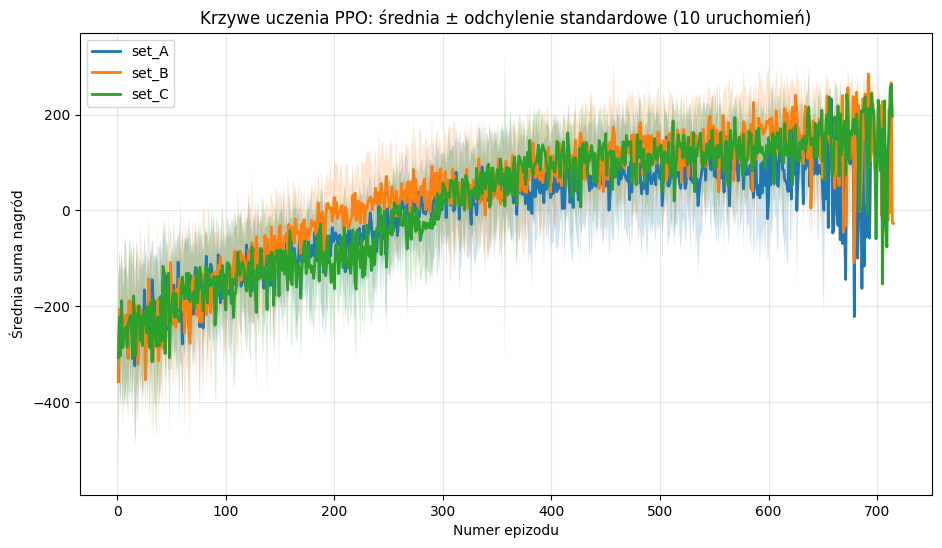

,set,final_reward_mean,final_reward_std,best_single_run_final,avg_training_time_s,avg_training_time_min,avg_step_time_s,avg_episode_time_s
1,set_B,155.950546,53.507694,241.792892,195.255829,3.254264,0.000651,0.307662
2,set_C,140.906723,38.058346,200.675079,496.479919,8.274665,0.001655,0.792996
0,set_A,105.924118,82.695290,193.822754,603.740234,10.062337,0.002012,0.982330


Saved: report_outputs\learning_curves.png
Saved: report_outputs\summary_metrics.csv


In [8]:
# Agregacja, wykres i tabela podsumowująca
def plot_results(results, savepath=None):
    plt.figure(figsize=(11, 6))
    for name, info in results.items():
        runs = info["rewards"]
        max_len = runs.shape[1]
        episodes = np.arange(1, max_len + 1)
        mean_curve = np.nanmean(runs, axis=0)
        std_curve = np.nanstd(runs, axis=0)

        plt.plot(episodes, mean_curve, linewidth=2, label=name)
        plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

    plt.xlabel("Numer epizodu")
    plt.ylabel("Średnia suma nagród")
    plt.title("Krzywe uczenia PPO: średnia ± odchylenie standardowe (10 uruchomień)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    if savepath is not None:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    plt.show()

def build_summary_table(results):
    rows = []
    for name, info in results.items():
        runs = info["rewards"]
        final_rewards = np.array([r[~np.isnan(r)][-10:].mean() if np.any(~np.isnan(r)) else np.nan for r in runs], dtype=np.float32)
        rows.append({
            "set": name,
            "final_reward_mean": float(np.nanmean(final_rewards)),
            "final_reward_std": float(np.nanstd(final_rewards)),
            "best_single_run_final": float(np.nanmax(final_rewards)),
            "avg_training_time_s": float(np.mean(info["run_times"])),
            "avg_training_time_min": float(np.mean(info["run_times"]) / 60.0),
            "avg_step_time_s": float(np.mean(info["step_times"])),
            "avg_episode_time_s": float(np.mean(info["episode_times"])),
        })

    return pd.DataFrame(rows).sort_values("final_reward_mean", ascending=False)

def load_results_from_npz(npz_path):
    data = np.load(npz_path)
    out = {}
    for name in hyper_sets.keys():
        out[name] = {
            "rewards": data[f"{name}_rewards"],
            "run_times": data[f"{name}_run_times"],
            "step_times": data[f"{name}_step_times"],
            "episode_times": data[f"{name}_episode_times"],
            "hyperparams": hyper_sets[name],
        }
    return out

if results is None:
    npz_path = OUTPUT_DIR / "results_raw.npz"
    if npz_path.exists():
        results = load_results_from_npz(npz_path)
        print("Loaded:", npz_path)
    else:
        print("Brak wyników: ustaw RUN_FULL_EXPERIMENT=True i uruchom komórkę treningu, żeby wygenerować wykresy i tabele.")
        summary_df = None
    
if results is not None:
    plot_path = OUTPUT_DIR / "learning_curves.png"
    plot_results(results, savepath=plot_path)
    summary_df = build_summary_table(results)
    display(summary_df)
    summary_df.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
    print("Saved:", plot_path)
    print("Saved:", OUTPUT_DIR / "summary_metrics.csv")

## Pomiar czasu kroku środowiska
Zanotujemy przybliżony czas wykonania jednego kroku `env.step()` aby opisać czas wykonywania eksperymentu.

In [9]:
# Pomiar czasu jednego kroku i jednego epizodu środowiska
def measure_env_step_time(n_steps=2000):
    env = make_env(seed=0)
    obs, info = env.reset(seed=0)
    t0 = time.time()

    for _ in range(n_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            obs, info = env.reset()

    dt = time.time() - t0
    env.close()
    return dt / n_steps

def measure_episode_time(n_episodes=10, max_steps=2000):
    env = make_env(seed=123)
    ep_times = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        t0 = time.time()
        for _ in range(max_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                break
        ep_times.append(time.time() - t0)

    env.close()
    return float(np.mean(ep_times)), float(np.std(ep_times))

step_time = measure_env_step_time(n_steps=2000)
episode_time_mean, episode_time_std = measure_episode_time(n_episodes=10)

timing_df = pd.DataFrame([
    {"metric": "env_step_time_s", "value": step_time},
    {"metric": "episode_time_mean_s", "value": episode_time_mean},
    {"metric": "episode_time_std_s", "value": episode_time_std},
])
display(timing_df)
timing_df.to_csv(OUTPUT_DIR / "timing_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "timing_metrics.csv")

,metric,value
0,env_step_time_s,0.000111
1,episode_time_mean_s,0.015594
2,episode_time_std_s,0.005269


Saved: report_outputs\timing_metrics.csv


**Wnioski**
# Opis architektur
Poniżej znajdują się krótkie opisy dwóch testowanych architektur. Po uruchomieniu następnej komórki generującej diagramy, obrazy pojawią się w katalogu `report_outputs/` i będą widoczne w tym notebooku.

**Architektura A — domyślna (64,64)**
- Wejście: wektor obserwacji środowiska (8 wartości: pozycje, prędkości, orientacja, kontakt nóg).
- Sieć: FC(64) -> Tanh -> FC(64) -> Tanh
- Wyjścia: actor head (parametry akcji), critic head (wartość stanu).

**Architektura B — powiększona (128,128)**
- Wejście: 8 wartości (jak wyżej).
- Sieć: FC(128) -> Tanh -> FC(128) -> Tanh
- Wyjścia: actor + critic (jak wyżej).




## Zadania na 8 punktow
1. Wszystkie zadania na 6 punktow.
2. Zapisz stan agenta z najlepszym wynikiem i uruchom test deterministyczny.
   Wynik testu porownaj z nagrodami z krzywej uczenia (srednia z koncowki).

In [ ]:
# Zapis najlepszego modelu i test deterministyczny
from pathlib import Path
import shutil

# Wskaznik, czy pokazac wizualizacje srodowiska
RENDER_DETERMINISTIC = True
BASE_SEED = 123

def resolve_best_model_zip(model_path):
    if model_path is None:
        return None
    p = Path(model_path)
    if p.suffix != ".zip":
        p = p.with_suffix(".zip")
    return p if p.exists() else None

def evaluate_deterministic(model_path, n_episodes=5, max_steps=MAX_STEPS, base_seed=BASE_SEED):
    render_mode = "human" if RENDER_DETERMINISTIC else None
    env = gym.make(ENV_ID, render_mode=render_mode)
    env.action_space.seed(base_seed)
    np.random.seed(base_seed)
    torch.manual_seed(base_seed)

    model = PPO.load(model_path)
    rewards = []
    for i in range(n_episodes):
        obs, info = env.reset(seed=base_seed + i)
        ep_reward = 0.0
        for _ in range(max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += float(reward)
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    env.close()
    return float(np.mean(rewards)), float(np.std(rewards))

best_zip = resolve_best_model_zip(best_model_path)
if best_zip is None:
    print("Brak zapisanego modelu. Uruchom trening (RUN_FULL_EXPERIMENT=True), aby zapisac najlepszy model.")
else:
    saved_best = OUTPUT_DIR / "best_model.zip"
    shutil.copy2(best_zip, saved_best)
    print("Zapisano najlepszy model ->", saved_best)

    det_mean, det_std = evaluate_deterministic(best_zip, n_episodes=5)
    print(f"Test deterministyczny (5 epizodow): mean={det_mean:.2f}, std={det_std:.2f}")

    tail_n = 10
    train_tail_mean = None
    if results is not None and best_config_name in results:
        rewards_mat = results[best_config_name]["rewards"]
        if rewards_mat.ndim == 2 and rewards_mat.shape[1] >= tail_n:
            tail_means = rewards_mat[:, -tail_n:].mean(axis=1)
            train_tail_mean = float(np.mean(tail_means))

Zapisano najlepszy model -> report_outputs\best_model.zip
Test deterministyczny (5 epizodow): mean=259.13, std=12.39


Wersja deterministyczna poradziła sobie nieznacznie lepiej. W trakcie samego procesu uczenia, PPO cały czas dodaje trochę szumu i losowości (eksploruje), żeby sprawdzać czy jest jakaś inna akcja która da lepsze skutki. Przez to cześciej agent poniekąd świadomie popełnia błedy. Kiedy w teście włączono tryb deterministyczny, agent wybierał tylko te akcje, co do których był przekonany, że są najlepsze. W praktyce przełożyło się to na wyższy i stabilniejszy wynik.